In [7]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
from scipy.spatial.transform import Slerp
from scipy.spatial.transform import RotationSpline
from scipy.interpolate import CubicSpline, interp1d
from scipy.linalg import null_space

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as CK, WhiteKernel as WK

from src.se3_lpvds.src.util import plot_tools, load_tools, process_tools, quat_tools
from src.se3_lpvds.src.se3_class import se3_class
from src.se3_lpvds.src.quaternion_ds.src.util.plot_tools import plot_traj as plot_traj_ori

In [8]:
import numpy as np
from scipy.spatial.transform import Rotation as R
import copy # If se3_obj needs deep copying


file_name = "infeasible_task2"
se3_obj = se3_class.load("models/" + file_name + "_ds.pkl")
quat_obj = se3_obj.ori_ds

dt = se3_obj.dt
q_in = se3_obj.q_in 
p_in = se3_obj.p_in
q_att = se3_obj.q_att
p_att = se3_obj.p_att
T = se3_obj.T

# Initial point from loaded data
q_0 = q_in[0]
p_0 = p_in[0]


def generate_nearby_rotations(ref_rot, num_samples=10, max_deviation_deg=5.0):
    random_vectors = np.random.randn(num_samples, 3)
    random_axes = random_vectors / np.linalg.norm(random_vectors, axis=1, keepdims=True)
    max_rad = np.radians(max_deviation_deg)
    random_angles = np.random.uniform(0, max_rad, size=(num_samples, 1))
    perturbation_vecs = random_axes * random_angles
    perturbations = R.from_rotvec(perturbation_vecs)
    random_starts = perturbations * ref_rot # right-multiply: local perturbation (usually better for "starting state")
    
    return random_starts


num_samples = 5
random_q0_list = generate_nearby_rotations(q_0, num_samples, max_deviation_deg=5.0) # plus one for testing
sim_results = []

print(f"Generating {len(random_q0_list)} variations...")

for i, q_start in enumerate(random_q0_list):
    p_res, q_res, _, _, _, _ = se3_obj.sim(
        p_0, 
        q_start, 
        p_att, 
        q_att, 
        dt, 
        duration=T*2
    )
    
    traj_rot = R.concatenate(q_res)
    traj_time = np.arange(0, dt * len(traj_rot), dt)

    sim_results.append({
        "q": traj_rot,
        "t": traj_time,
        "label": f"Sim {i}"
    })

t_in = sim_results[0]["t"] # needed for generating interpolants

[INFO] Model loaded successfully from models/infeasible_task2_ds.pkl
Generating 5 variations...
Converged within max iteration
Converged within max iteration
Converged within max iteration
Converged within max iteration
Converged within max iteration


In [9]:
# file_name = "infeasible_task2"
# se3_obj = se3_class.load("models/" + file_name + "_ds.pkl")

# dt = se3_obj.dt
# q_in = se3_obj.q_in
# p_in = se3_obj.p_in
# q_out = se3_obj.q_out
# q_att = se3_obj.q_att
# p_att = se3_obj.p_att
# quat_obj = se3_obj.ori_ds
# t_in = se3_obj.t_in
# T =se3_obj.T

# # using simulation rollout for training
# q_0 = q_in[0]
# p_0 = p_in[0]
# p_test, q_test, gamma_pos, gamma_ori, v_test, w_test = se3_obj.sim(p_0, q_0, p_att, q_att, step_size=dt, duration=T*2)
# q_in = R.concatenate(q_test)
# t_in = np.arange(0, dt*len(q_in), dt)

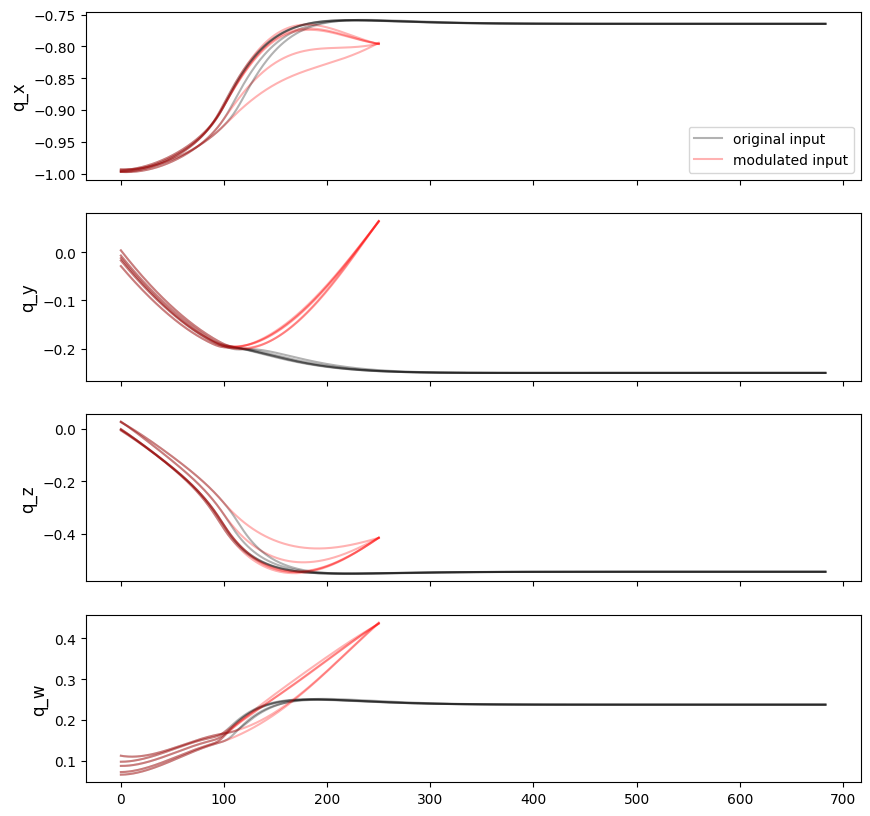

In [10]:
def cubic_spline_quat(key_rots, key_times, time_interp):
    quats = np.array([rot.as_quat() for rot in key_rots])
    for i in range(1, len(quats)):
        if np.dot(quats[i], quats[i-1]) < 0:
            quats[i] = -quats[i]
    cs = CubicSpline(key_times, quats, bc_type='natural')
    interp_quats = cs(time_interp)
    interp_quats = interp_quats / np.linalg.norm(interp_quats, axis=1, keepdims=True)
    return R.from_quat(interp_quats)

def robust_rotation_spline(key_rots, key_times, time_interp):
    # RotationSpline handles the spherical geometry and angular rates correctly
    spline = RotationSpline(key_times, key_rots)
    return spline(time_interp)

def slerp_quat(key_rots, key_times, time_interp):
    slerp = Slerp(key_times, key_rots)
    return slerp(time_interp)

start_idx = 100
mid_idx   = 250

q_interp_list = []
for idx, q_sim_dict in enumerate(sim_results):
    ## idx_list  = np.arange(len(q_in)).tolist()
    idx_list  = np.arange(start_idx).tolist()+ [mid_idx] #+ np.arange(end_idx, len(t_in)).tolist()
    key_times = [t_in[idx] for idx in idx_list]
    key_rots  = R.concatenate([q_sim_dict["q"][idx] for idx in idx_list])
    key_rots[start_idx] *= R.from_euler('XYZ', [0, 0, 45], degrees=True)  # add perturbation for testing
    idx_interp = np.arange(idx_list[0], idx_list[-1]+1)
    time_interp = [t_in[idx] for idx in idx_interp]
    q_interp = cubic_spline_quat(key_rots, key_times, time_interp)
    q_interp_list.append(q_interp)


fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)
component_names = ['x', 'y', 'z', 'w']
for idx, q_sim_dict in enumerate(sim_results):
    if idx == 0:
        for i, (ax, name) in enumerate(zip(axes, component_names)):
            ax.plot(q_sim_dict["q"].as_quat()[:, i], 'k-', alpha=0.3, label='original input', linewidth=1.5)
            ax.plot(q_interp_list[idx].as_quat()[:, i], 'r-', alpha=0.3, label='modulated input', linewidth=1.5)
            ax.set_ylabel(f'q_{name}', fontsize=12)
    else:
        for i, (ax, name) in enumerate(zip(axes, component_names)):
            ax.plot(q_sim_dict["q"].as_quat()[:, i], 'k-', alpha=0.3, linewidth=1.5)
            ax.plot(q_interp_list[idx].as_quat()[:, i], 'r-', alpha=0.3, linewidth=1.5)
axes[0].legend(loc='best')

In [11]:
def compute_original_output(q):
    q_out_m_o = [] # original output of modulation data
    for q_i in q:
        q_next, _, _ = quat_obj._step(q_i, dt)
        q_out_m_o.append(q_next)
    return R.concatenate(q_out_m_o)

start_idx_rf = start_idx
end_idx_rf  = mid_idx

idx_rf_list = [i for i in np.arange(start_idx_rf, end_idx_rf)]

q_in_m_list = []
q_out_m_list = []
q_out_m_o_list = []

for q_interp in q_interp_list:
    q_in_m  = q_interp[start_idx_rf: end_idx_rf]
    q_out_m = q_interp[start_idx_rf+1:end_idx_rf+1] # modulated output
    q_out_m_o = compute_original_output(q_in_m)
    q_in_m_list.append(q_in_m)
    q_out_m_list.append(q_out_m)
    q_out_m_o_list.append(q_out_m_o)

Text(0.5, 0.92, '3D Visualization of Quaternion Outputs')

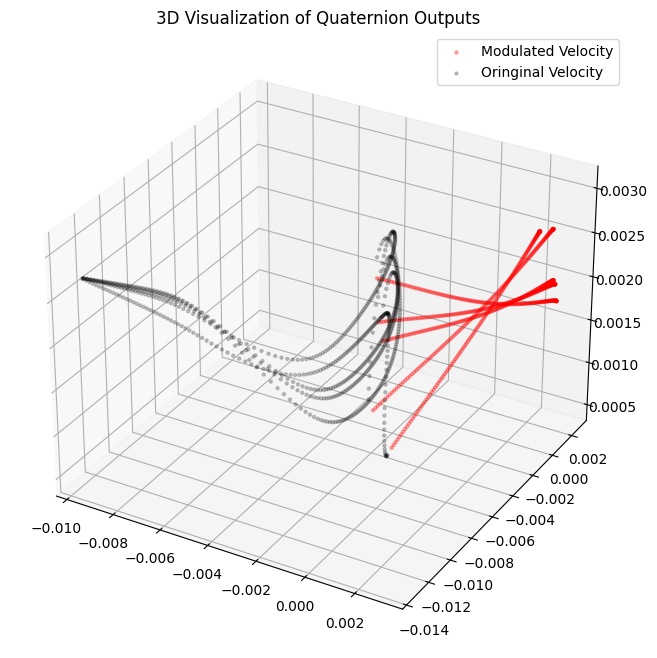

In [12]:
def map(att_vec, q):
    #4d to 3d
    att_basis = null_space(att_vec.as_quat().reshape(1, -1))
    v, _, _, _ = np.linalg.lstsq(att_basis, q, rcond=None)
    return v

def inv_map(att_vec, v):
    #3d to 4d
    att_basis = null_space(att_vec.as_quat().reshape(1, -1))
    q_tangent = att_basis @ v               
    return q_tangent

def modulation_param(x_ori, x_mod):
    mu = np.cross(x_ori, x_mod) #/ (np.linalg.norm(x_ori) * np.linalg.norm(x_mod)) # rotation vector
    mu = mu / np.linalg.norm(mu + 1e-10)  # normalize

    phi = np.arccos(np.clip(np.dot(x_ori, x_mod) / (np.linalg.norm(x_ori) * np.linalg.norm(x_mod)), -1.0, 1.0)) # rotation angle
    kappa = np.linalg.norm(x_mod) / np.linalg.norm(x_ori) - 1.0
    return mu, phi, kappa

def modulation_matrix(mu_phi, kappa):
    M = (1+kappa) * R.from_rotvec(mu_phi).as_matrix() 
    return M

def return_q_out(q_att, q_in, q_out): 
    q_out_body      = quat_tools.riem_log(q_in, q_out)
    q_out_att_4d    = quat_tools.parallel_transport(q_in, q_att, q_out_body)[0]
    q_out_att = map(q_att, q_out_att_4d)
    return q_out_att


X_train = []
y_train = []
q_out_3d = []
q_out_o_3d = []

X_train_list = []# for plotting
y_train_list = []

for q_in_m, q_out_m, q_out_m_o in zip(q_in_m_list, q_out_m_list, q_out_m_o_list): # iterate over trajectories
    for qin, qout, qout_o in zip(q_in_m, q_out_m, q_out_m_o): # iterate over waypoints
        q_out_att   = return_q_out(q_att, qin, qout) 
        q_out_att_m = return_q_out(q_att, qin, qout_o)
        q_out_3d.append(q_out_att)
        q_out_o_3d.append(q_out_att_m)

        mu, phi, kappa = modulation_param(q_out_att_m, q_out_att)
        X_train.append(quat_tools.riem_log(q_att, qin))
        y_train.append(np.hstack((kappa, phi * mu[0], phi * mu[1], phi * mu[2])).reshape(1, -1))  # 4*1 vector

        # X_train_list.append(X_train)
    # y_train_list.append(y_train)

X_train   = np.vstack(X_train)
y_train   = np.vstack(y_train)
idx_train = np.vstack(idx_rf_list)

q_out_3d = np.vstack(q_out_3d)
q_out_o_3d = np.vstack(q_out_o_3d)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(q_out_3d[:, 0], q_out_3d[:, 1], q_out_3d[:, 2], c='red', s=5, alpha=0.3, label='Modulated Velocity')
ax.scatter(q_out_o_3d[:, 0], q_out_o_3d[:, 1], q_out_o_3d[:, 2], c='black', s=5, alpha=0.2, label='Oringinal Velocity')
ax.legend()
ax.set_title('3D Visualization of Quaternion Outputs')


In [13]:
# sigma_f = 0.5       # signal std
# l_scale = 0.2         # length scale
# sigma_n = 0.1    # noise std
# kernel = CK(sigma_f**2, (1e-6, 1e6)) * RBF(length_scale=l_scale, length_scale_bounds=(1e-6, 1e6)) \
#          + WK(noise_level=sigma_n**2, noise_level_bounds=(1e-6, 1))
# gpr = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=10)
# gpr.fit(X_train, y_train) 
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as CK

# # Updated parameters for better responsiveness and generalization
sigma_f = 0.3       # Increased slightly to allow for higher peaks
l_scale = 0.1       # Decreased to allow the GP to follow sharper curves
sigma_n = 0.05      # Increased to account for the spread between red lines

# # Use a Matern kernel for better flexibility with physical movements

kernel = CK(sigma_f**2, (1e-3, 1e3)) * \
         Matern(length_scale=l_scale, length_scale_bounds=(0.1, 10.0), nu=1.5) + \
         WhiteKernel(noise_level=sigma_n**2, noise_level_bounds=(1e-5, 0.1))

gpr = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=10)

gpr.fit(X_train, y_train)

joblib.dump(gpr, "models/"+file_name+"_gpr.pkl")
gpr = joblib.load("models/"+file_name+"_gpr.pkl")

/Users/sunansun/miniconda3/envs/venv3.11/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 14 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/sunansun/miniconda3/envs/venv3.11/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


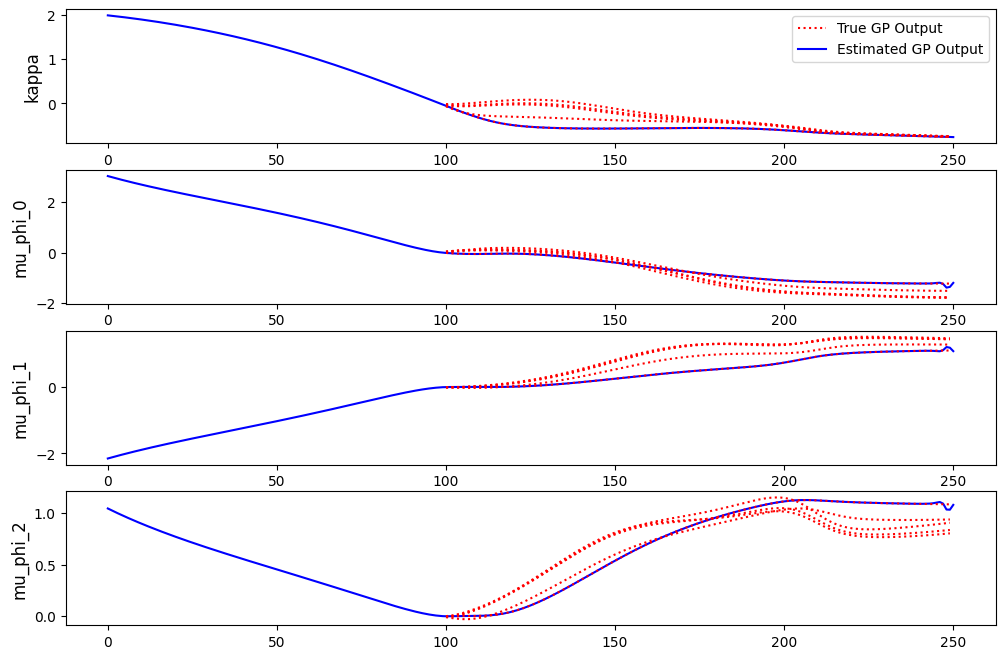

In [14]:
y_train_est, _ = gpr.predict(X_train, return_std=True)

X_test = np.vstack([quat_tools.riem_log(q_att, q) for q in q_interp])
y_test_est, _ = gpr.predict(X_test, return_std=True)

fig, axs = plt.subplots(4, 1, figsize=(12, 8))
component_names = ['kappa', 'mu_phi_0', 'mu_phi_1', 'mu_phi_2']
for i in range(num_samples):
    for k in range(4):
        if i == 0:
            axs[k].plot(idx_train, y_train[i*len(idx_train):(i+1)*len(idx_train), k], c='r', linestyle='dotted', label="True GP Output", zorder=2)
        else:
            axs[k].plot(idx_train, y_train[i*len(idx_train):(i+1)*len(idx_train), k], c='r', linestyle='dotted', zorder=2)
for k in range(4):
    axs[k].plot(y_test_est[:, k], c='b',label="Estimated GP Output", zorder=1)
    axs[k].set_ylabel(f'{component_names[k]}', fontsize=12)

axs[0].legend(loc='best')

In [15]:
# """The test is to see if we can use the regressed modulated parameters to retrieve the true modulated output"""

# # Step 1: Retrieve the input, original output and modulated output
# q_in = q_in_m_list[0][100]
# q_out = q_out_m_list[0][100]
# q_out_o = q_out_m_o_list[0][100]

# # Step 2: Verify the modulation parameter
# q_out_3d   = return_q_out(q_att, q_in, q_out) 
# q_out_o_3d = return_q_out(q_att, q_in, q_out_o)
# mu, phi, kappa = modulation_param(q_out_o_3d, q_out_3d)
# print("Reference modulated 3d output:", q_out_3d)

# # Step 2.5 Verify reconstruction
# M = modulation_matrix(mu * phi, kappa)
# q_out_recon_3d = M @ q_out_o_3d.reshape(-1, 1)
# print("Reconstrcuted modulated 3d output:", q_out_recon_3d.flatten()) # test passed!
# print("Reference modulation parameters:")
# print("kappa:", kappa)
# print("mu_phi_0:", mu [0] * phi)
# print("mu_phi_1:", mu [1] * phi)
# print("mu_phi_2:", mu [2] * phi)

# # Step 3: Reconstruct the modulated output using the estimated parameters
# q_next, gamma, omega, y_mean = quat_obj._step2(q_in, dt, gpr)
# print("Regressed modulation parameter:")
# print("kappa:", y_mean[0, 0])
# print("mu_phi_0:", y_mean[0, 1])
# print("mu_phi_1:", y_mean[0, 2])
# print("mu_phi_2:", y_mean[0, 3])
# print("Reference modulated output quaternion:", q_out.as_quat())
# print("Reconstructed modulated output quaternion:", q_next.as_quat())

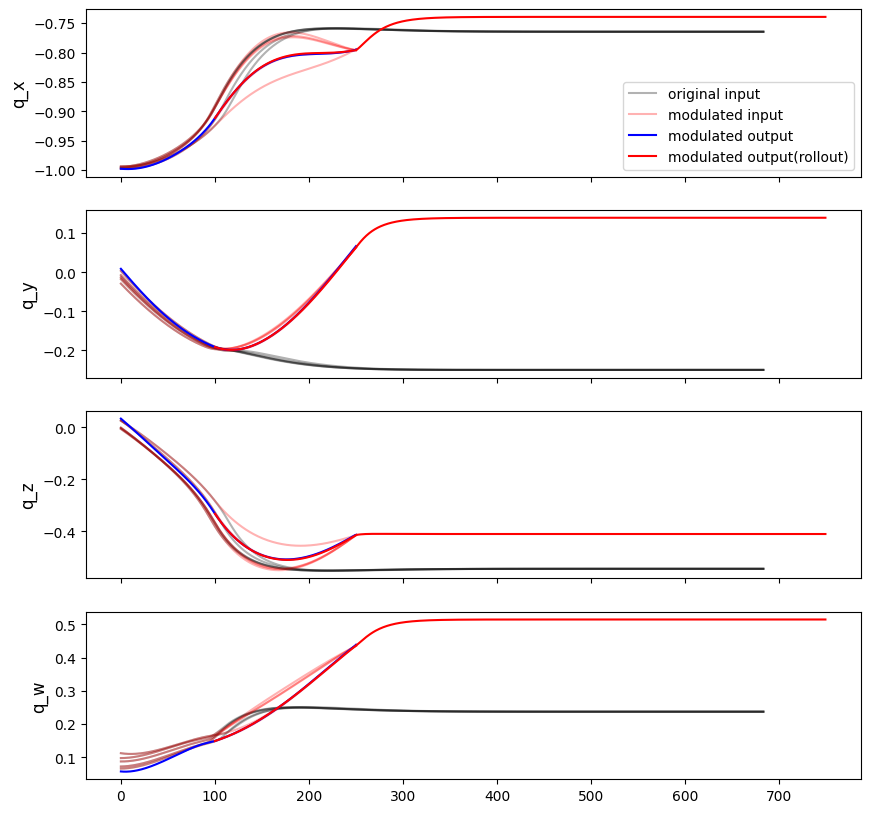

In [16]:
def compute_output(q):
    q_list =[] # estimated modulated output of modulation data
    y_list =[]
    for q_i in q:
        q_next, _,_,y = quat_obj._step2(q_i, dt, gpr)
        q_list.append(q_next)
        y_list.append(y)
    return R.concatenate(q_list), np.vstack(y_list)

def rollout_output(q, idx_test):
    q_curr = q
    q_list =[]
    y_list =[]
    for _ in range(idx_test.shape[0]):
        q_next, _, _, y= quat_obj._step2(q_curr, dt, gpr)
        q_list.append(q_next)
        y_list.append(y)
        q_curr = q_next
    return R.concatenate(q_list), np.vstack(y_list)



idx_test = np.arange(start_idx, mid_idx+500)
q_rollout_m, y_rollout = rollout_output(q_interp_list[0][start_idx]*R.from_euler('XYZ', [0, 0, 0], degrees=True), idx_test)
q_out_m_est, y_est = compute_output(q_interp_list[0])


fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)
component_names = ['x', 'y', 'z', 'w']
for idx, q_sim_dict in enumerate(sim_results):
    if idx == 0:
        for i, (ax, name) in enumerate(zip(axes, component_names)):
            ax.plot(q_sim_dict["q"].as_quat()[:, i], 'k-', alpha=0.3, label='original input', linewidth=1.5)
            ax.plot(q_interp_list[idx].as_quat()[:, i], 'r-', alpha=0.3, label='modulated input', linewidth=1.5)
            ax.set_ylabel(f'q_{name}', fontsize=12)
    else:
        for i, (ax, name) in enumerate(zip(axes, component_names)):
            ax.plot(q_sim_dict["q"].as_quat()[:, i], 'k-', alpha=0.3, linewidth=1.5)
            ax.plot(q_interp_list[idx].as_quat()[:, i], 'r-', alpha=0.3, linewidth=1.5)


component_names = ['x', 'y', 'z', 'w']
for i, (ax, name) in enumerate(zip(axes, component_names)):
    ax.plot(q_out_m_est.as_quat()[:, i], color='b', label='modulated output')
    ax.plot(idx_test, q_rollout_m.as_quat()[:, i],  color='r', label='modulated output(rollout)')


axes[0].legend(loc='best')